In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error

In [2]:
base_folder = '/dat/andreuva/gpu/graphnet/graphnet_nlte/checkpoints/multistride_cpudtst_4x4_s4_m8_b8_r6_d025_press/'

In [3]:
lte_intensities = [f'Iwave_lte_stride_{i+1}_test.npy' for i in range(5)]
target_intensities = [f'Iwave_target_stride_{i+1}_test.npy' for i in range(5)]
predicted_intensities = [f'Iwave_predicted_stride_{i+1}_test.npy' for i in range(5)]

predicted_pops = [f'predictions_patch_stride_{i+1}_test.npy' for i in range(5)]
target_pops = [f'targets_patch_stride_{i+1}_test.npy' for i in range(5)]

In [4]:
lte_intensities = [np.load(base_folder + intens) for intens in lte_intensities]
target_intensities = [np.load(base_folder + intens) for intens in target_intensities]
predicted_intensities = [np.load(base_folder + intens) for intens in predicted_intensities]

predicted_pops = [np.load(base_folder + pops) for pops in predicted_pops]
target_pops = [np.load(base_folder + pops) for pops in target_pops]

In [5]:
# 1. LOAD DATA
# Adjust the file paths to match where your notebooks saved the outputs.
# Typically these would be .npy files containing arrays of shape (N_pixels, N_levels)

try:
    # Ground Truth (computed by Multi3D)
    # Shape: (N_samples, 6) -> 5 levels + continuum
    populations_true = {
        1: np.load(base_folder+'targets_patch_stride_1_test.npy'),
        2: np.load(base_folder+'targets_patch_stride_2_test.npy'),
        3: np.load(base_folder+'targets_patch_stride_3_test.npy'),
        4: np.load(base_folder+'targets_patch_stride_4_test.npy'),
        5: np.load(base_folder+'targets_patch_stride_5_test.npy')
    }
    
    # Load predictions for different strides
    # These would have been generated by 'stride_tests.ipynb'
    predictions = {
        1: np.load(base_folder+'predictions_patch_stride_1_test.npy'),
        2: np.load(base_folder+'predictions_patch_stride_2_test.npy'),
        3: np.load(base_folder+'predictions_patch_stride_3_test.npy'),
        4: np.load(base_folder+'predictions_patch_stride_4_test.npy'),
        5: np.load(base_folder+'predictions_patch_stride_5_test.npy')
    }
    print("Data loaded successfully.")

except FileNotFoundError as e:
    print(f"Error loading files: {e}")
    print("Please ensure you have exported the predictions to .npy files.")

Data loaded successfully.


In [6]:
# 2. METRIC CALCULATION WITH RESHAPE
results_s = []
mean_rel_errors = [] # Changed from mse_list
rel_errors = []
r2s = []

# Sort by stride to ensure plot is ordered
for stride in sorted(predictions.keys()):
    preds = predictions[stride]
    pops = populations_true[stride]
    
    n_levels = preds.shape[-1]
    preds_flat = preds.reshape(-1, n_levels)
    targets_flat = pops.reshape(-1, n_levels)
    
    # --- COMPUTE METRICS ---
    
    # 1. R2 Score for each level
    r2_scores = [r2_score(targets_flat[:, i], preds_flat[:, i]) for i in range(n_levels)]

    epsilon = 1e-16 # small constant to avoid division by zero
    relative_errors = np.abs(targets_flat - preds_flat) / (np.abs(targets_flat) + epsilon) * 100
    # cut the outliers for better visualization (99th percentile)
    relative_errors = np.clip(relative_errors, 0*np.ones(n_levels), np.percentile(relative_errors, 95, axis=0))
    
    results_s.append(stride)
    mean_rel_errors.append(np.mean(relative_errors, axis=0))
    rel_errors.append(relative_errors)
    r2s.append(r2_scores)

In [7]:
rel_errors_s = [np.moveaxis(rel_errors[i], 1, 0) for i in range(len(results_s))]
results_errors_n = []
for i in range(n_levels):
    results_errors_n.append([rel_errors_s[j][i] for j in range(len(results_s))])

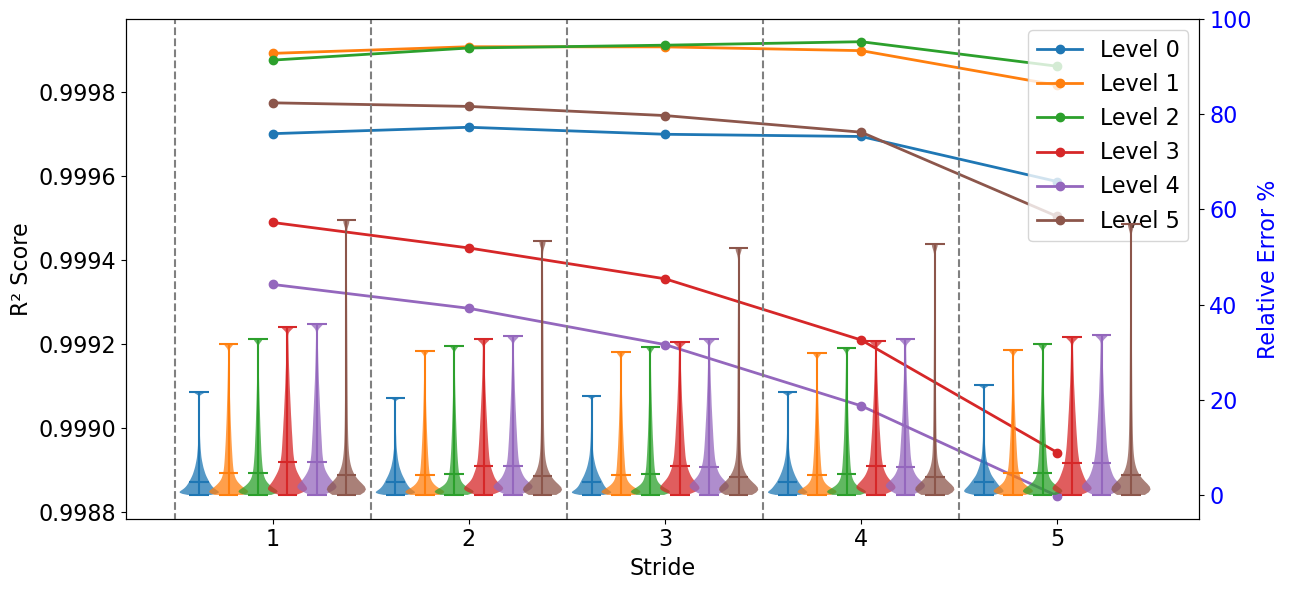

In [8]:
# ==============================================================================
# 3. VISUALIZATION
# ==============================================================================
fig, ax1 = plt.subplots(figsize=(13, 6), dpi=100)

# Plot Relative Error on a secondary axis
ax2 = ax1.twinx()
color = 'blue'
# Updated label
ax2.set_ylabel('Relative Error %', color=color, fontsize=16) 
# Updated data source to rel_error_list
# ax2.plot(results_s, mean_rel_errors, marker='s', linestyle='--', color=color, linewidth=2, label='Relative Error')
for i in range(n_levels):
    vp = ax2.violinplot(results_errors_n[i], positions=[s-0.375 + i*0.15 for s in results_s], widths=0.2, showmedians=True)
    for vio in vp['bodies']:
        vio.set_alpha(0.75)
ax2.vlines([np.linspace(0.5, 4.5, 5)], -10, 100, colors='gray', linestyles='dashed')
ax2.tick_params(axis='y', labelcolor=color, labelsize=16)
ax2.set_ylim(-5, 100)

# Plot R2 Score (Accuracy)
ax1.set_xlabel('Stride', fontsize=16)
ax1.set_ylabel('R² Score', fontsize=16)
for i in range(n_levels):
    ax1.plot(results_s, [r2s[j][i] for j in range(len(results_s))], marker='o', linestyle='-', linewidth=2, label=f'Level {i}')
ax1.tick_params(axis='y', labelsize=16)

from matplotlib.ticker import MaxNLocator
ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
# Alternatively, since we have discrete steps, we can just set them explicitly:
ax1.set_xticks(results_s)
ax1.tick_params(axis='x', labelsize=16)

# plt.title('Impact of Graph Stride on Prediction Accuracy vs Relative Error', fontsize=14)
ax1.legend(loc='upper right', fontsize=16)
plt.tight_layout()
plt.show()